# Project 1 — Exploratory Data Analysis

**The Price of Fairness: Constrained Risk Pricing**

Question this project ultimately asks: *what does fairness actually cost in risk pricing?*

This notebook explores the synthetic policy/claim dataset produced by `data/generate_data.py`. Focus areas for Week 1:

- What does the dataset look like (schema, size, quality)?
- What is the claim process like (frequency, severity, zero-inflation)?
- Do base rates differ across protected groups (gender, territory) — the precondition for a meaningful fairness analysis?

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Allow running from the repo root or from inside notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "sample_claims.csv"
plt.rcParams["figure.dpi"] = 110

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} policies from {DATA_PATH.name}")
df.head()

Loaded 10,000 policies from sample_claims.csv


,policy_id,age,gender,territory,vehicle_type,annual_miles,driving_experience_years,exposure,claim_count,total_claim_amount
0,P0000001,23,F,A,truck,29209,5.9,0.6457,0,0.0
1,P0000002,66,M,A,truck,9272,50.7,0.5604,0,0.0
2,P0000003,59,M,A,truck,14440,41.1,0.5537,0,0.0
3,P0000004,45,F,C,sedan,9511,27.7,0.5047,0,0.0
4,P0000005,45,F,B,suv,18774,28.4,0.9892,0,0.0


In [3]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   policy_id                 10000 non-null  str    
 1   age                       10000 non-null  int64  
 2   gender                    10000 non-null  str    
 3   territory                 10000 non-null  str    
 4   vehicle_type              10000 non-null  str    
 5   annual_miles              10000 non-null  int64  
 6   driving_experience_years  10000 non-null  float64
 7   exposure                  10000 non-null  float64
 8   claim_count               10000 non-null  int64  
 9   total_claim_amount        10000 non-null  float64
dtypes: float64(3), int64(3), str(4)
memory usage: 921.9 KB

Missing values per column:
policy_id                   0
age                         0
gender                      0
territory                   0
vehicle_type                0
annua

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10000.0,48.772700,18.100873,18.0000,33.000000,49.0000,64.000,80.0
annual_miles,10000.0,20633.850900,8960.857436,5000.0000,12932.750000,20706.0000,28436.000,35998.0
driving_experience_years,10000.0,31.799420,18.224361,0.0000,16.100000,31.7000,47.300,68.2
exposure,10000.0,0.750124,0.143952,0.5001,0.626375,0.7517,0.874,1.0
claim_count,10000.0,0.130100,0.367950,0.0000,0.000000,0.0000,0.000,4.0
total_claim_amount,10000.0,484.985004,1808.016515,0.0000,0.000000,0.0000,0.000,33473.4


## The claim process at a glance

Auto insurance data is zero-inflated: most policies have no claim in a year. The interesting action is in the tail — a small share of policies drives most of the losses.

In [5]:
claim_rate = (df["claim_count"] > 0).mean()
mean_freq = df["claim_count"].mean()
mean_loss = df["total_claim_amount"].mean()
mean_sev = df.loc[df["claim_count"] > 0, "total_claim_amount"].mean()

print(f"Policies with >= 1 claim:  {claim_rate:.1%}")
print(f"Mean claim count (all):     {mean_freq:.3f}")
print(f"Mean loss per policy:       ${mean_loss:,.0f}   <- pure premium proxy")
print(f"Mean severity given claim:  ${mean_sev:,.0f}")

Policies with >= 1 claim:  12.0%
Mean claim count (all):     0.130
Mean loss per policy:       $485   <- pure premium proxy
Mean severity given claim:  $4,042


## Base rates by protected group

The fairness debate only bites when groups genuinely differ. Here, by construction, gender and territory shift both claim frequency and severity — so we can later ask *what it costs* to remove those differences from pricing.

In [6]:
def segment_table(group_cols):
    tab = df.groupby(group_cols).agg(
        n_policies=("policy_id", "count"),
        claim_frequency=("claim_count", "mean"),
        claim_rate=("claim_count", lambda s: (s > 0).mean()),
        avg_loss_per_policy=("total_claim_amount", "mean"),
    )
    sev = (
        df.loc[df["claim_count"] > 0]
        .groupby(group_cols)["total_claim_amount"]
        .mean()
        .rename("avg_severity_given_claim")
    )
    return tab.join(sev).round(4)

segment_table(["gender"])

,n_policies,claim_frequency,claim_rate,avg_loss_per_policy,avg_severity_given_claim
gender,,,,,
F,5167,0.1152,0.1064,426.0101,4002.1715
M,4833,0.1461,0.1345,548.0355,4074.8550


In [7]:
segment_table(["territory"])

,n_policies,claim_frequency,claim_rate,avg_loss_per_policy,avg_severity_given_claim
territory,,,,,
A,3958,0.1006,0.0960,302.9772,3155.7468
B,3470,0.1268,0.1167,445.4879,3816.8965
C,2572,0.1800,0.1614,818.3605,5071.8630


In [8]:
segment_table(["gender", "territory"])

n_policies  claim_frequency  claim_rate  \
gender territory                                            
F      A                2039           0.0897      0.0868   
       B                1796           0.1091      0.0997   
       C                1332           0.1622      0.1456   
M      A                1919           0.1120      0.1058   
       B                1674           0.1458      0.1350   
       C                1240           0.1992      0.1782   

                  avg_loss_per_policy  avg_severity_given_claim  
gender territory                                                 
F      A                     262.5360                 3024.3550  
       B                     373.5512                 3748.0329  
       C                     746.9862                 5128.7917  
M      A                     345.9473                 3270.3101  
       B                     522.6674                 3871.4389  
       C                     895.0303                 5021.8895

## Distributions

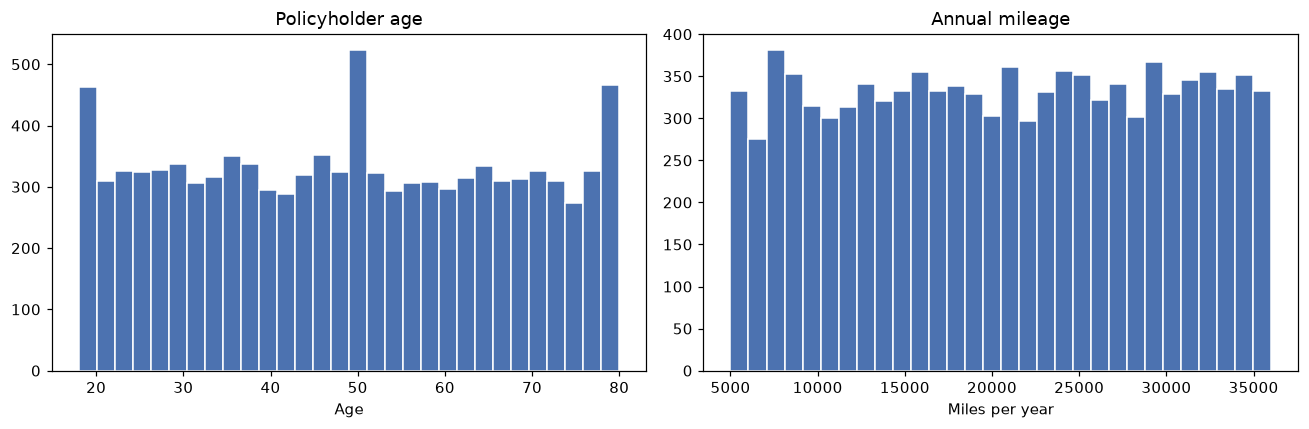

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["age"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Policyholder age")
axes[0].set_xlabel("Age")
axes[1].hist(df["annual_miles"], bins=30, color="#4C72B0", edgecolor="white")
axes[1].set_title("Annual mileage")
axes[1].set_xlabel("Miles per year")
plt.tight_layout()
plt.show()

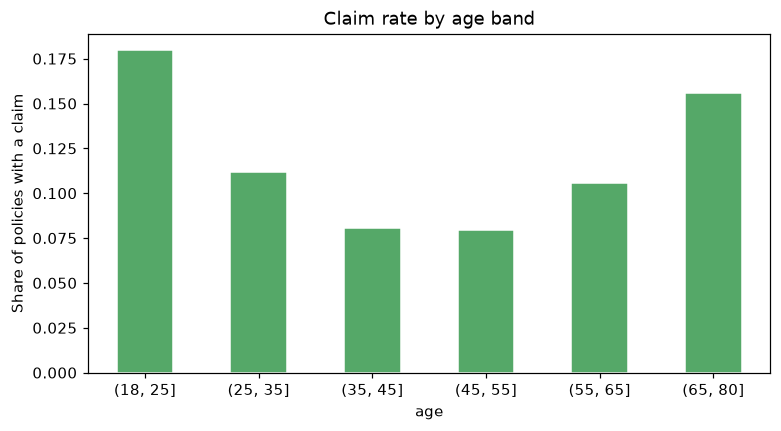

In [10]:
age_bands = pd.cut(df["age"], bins=[18, 25, 35, 45, 55, 65, 80], right=True)
rate_by_age = df.groupby(age_bands, observed=True)["claim_count"].apply(lambda s: (s > 0).mean())

fig, ax = plt.subplots(figsize=(8, 4))
rate_by_age.plot.bar(ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Claim rate by age band")
ax.set_ylabel("Share of policies with a claim")
plt.xticks(rotation=0)
plt.show()

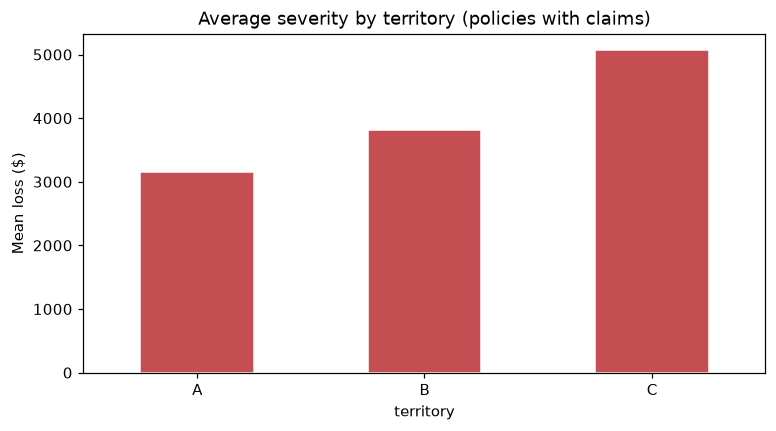

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
df.loc[df["claim_count"] > 0].groupby("territory")["total_claim_amount"].mean().plot.bar(
    ax=ax, color="#C44E52", edgecolor="white"
)
ax.set_title("Average severity by territory (policies with claims)")
ax.set_ylabel("Mean loss ($)")
plt.xticks(rotation=0)
plt.show()

## Correlations and the pure-premium cross-tab

In [12]:
numeric = ["age", "annual_miles", "driving_experience_years", "exposure", "claim_count", "total_claim_amount"]
df[numeric].corr().round(3)

,age,annual_miles,driving_experience_years,exposure,claim_count,total_claim_amount
age,1.000,0.011,0.994,0.006,0.012,0.112
annual_miles,0.011,1.000,0.009,0.002,0.024,0.023
driving_experience_years,0.994,0.009,1.000,0.006,0.011,0.111
exposure,0.006,0.002,0.006,1.000,0.076,0.056
claim_count,0.012,0.024,0.011,0.076,1.000,0.763
total_claim_amount,0.112,0.023,0.111,0.056,0.763,1.000


In [13]:
premium = df.pivot_table(
    index="gender", columns="territory", values="total_claim_amount", aggfunc="mean"
)
premium.round(0)

territory,A,B,C
gender,,,
F,263.0,374.0,747.0
M,346.0,523.0,895.0


## Initial observations

* Claim frequency is low and zero-inflated — most policies have no claim, which is realistic for auto insurance.
* Base rates differ across protected groups by construction: gender and territory shift both claim frequency and severity, so fairness questions are meaningful in this dataset.
* The pure-premium cross-tab shows clear segment-level differences, which becomes the "who pays more" story.
* `total_claim_amount` is right-skewed — a few large losses dominate — which motivates the severity model and, later, tail analysis.